In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [131]:
# load training data and test data

df = pd.read_csv('data/train_data.csv')
df_TEST = pd.read_csv('data/test_data.csv')

In [132]:
df

,engine_id,cycle,altitude,mach_number,LPC_outlet_temp,HPC_outlet_temp,LPT_outlet_temp,bypass_press,HPC_outlet_press,fan_speed,core_speed,HPC_static_outlet_press,fuel_flow_ratio,corrected_fan_speed,corrected_core_speed,bypass_ratio,bleed_enthalpy,HPT_coolant_bleed,LPT_coolant_bleed,RUL
0,1_FD001,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,150
1,1_FD001,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,150
2,1_FD001,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,150
3,1_FD001,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,150
4,1_FD001,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,150
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16732,99_FD001,181,-0.0015,-0.0001,643.72,1600.39,1428.03,21.61,551.09,2388.27,9054.88,48.23,519.60,2388.29,8123.55,8.4885,396,38.50,23.0425,4
16733,99_FD001,182,-0.0027,-0.0003,643.52,1605.33,1430.32,21.61,551.61,2388.26,9063.31,48.16,519.32,2388.27,8130.99,8.5124,393,38.39,22.9674,3
16734,99_FD001,183,-0.0031,-0.0003,643.96,1606.95,1427.90,21.61,550.86,2388.32,9055.80,48.48,519.69,2388.31,8126.90,8.5374,395,38.57,23.1440,2
16735,99_FD001,184,-0.0010,-0.0001,644.10,1600.20,1436.54,21.61,551.51,2388.29,9060.79,48.12,519.84,2388.33,8125.66,8.5592,395,38.45,23.0478,1


In [133]:
column_names = df.columns.tolist()

In [134]:
# split for training/validation + test data by engine_id

# number of unique engines
num_engines = df['engine_id'].nunique()
engines = df['engine_id'].unique()
num_engines_train = int(num_engines * 0.8)
engines_train = engines[-num_engines_train:]

df_TRAIN = df[df['engine_id'].isin(engines_train)]
df_VAL = df[~df['engine_id'].isin(engines_train)]

In [135]:
# create windows of data for LSTM input

def create_windows(df, window_size=5, step_size=1):
    X, y = [], []
    engine_ids = df['engine_id'].unique()
    
    for engine_id in engine_ids:
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')
        features = engine_data.drop(columns=['engine_id', 'RUL']).values
        rul_values = engine_data['RUL'].values
        
        for start in range(0, len(engine_data) - window_size + 1, step_size):
            end = start + window_size
            X.append(features[start:end])
            y.append(rul_values[start:end])  # (sequence-to-sequence)
    
    return np.array(X), np.array(y)

In [136]:
# normalization

numeric_cols = df_TRAIN.select_dtypes(include="number").columns

train_mean = df_TRAIN[numeric_cols].mean()
train_std = df_TRAIN[numeric_cols].std()

df_TRAIN[numeric_cols] = (df_TRAIN[numeric_cols] - train_mean) / train_std
df_VAL[numeric_cols] = (df_VAL[numeric_cols] - train_mean) / train_std
df_TEST[numeric_cols] = (df_TEST[numeric_cols] - train_mean) / train_std

norm_vals = {
    'X_mean': train_mean[train_mean.index != 'RUL'].to_numpy().tolist(),
    'X_std': train_std[train_std.index != 'RUL'].to_numpy().tolist(),
    'y_mean': train_mean[train_mean.index == 'RUL'].to_numpy().tolist(),
    'y_std': train_std[train_std.index == 'RUL'].to_numpy().tolist()
}

artifacts = {}
artifacts['normalization_factors'] = norm_vals

In [137]:
artifacts

{'normalization_factors': {'X_mean': [111.89727603354858,
   -1.7026645884361314e-05,
   4.690863207897277e-06,
   642.6733615378905,
   1590.4296533808356,
   1408.8293475840567,
   21.609808505900695,
   553.3774704965485,
   2388.0951243227196,
   9065.300051955763,
   47.536514510502485,
   521.4233993913754,
   2388.0948289170933,
   8143.845596377941,
   8.44174368737475,
   393.1889705336599,
   38.81854152749945,
   23.29119157574408],
  'X_std': [71.70521841838726,
   0.0021890900072711133,
   0.0002930438000595809,
   0.49633245588597746,
   6.1003798962328295,
   8.92450121016033,
   0.0013705511385496214,
   0.8718786451801641,
   0.06866171548074432,
   20.645556322613878,
   0.2642269178549956,
   0.7275599160234318,
   0.06958501794159318,
   17.720814193719313,
   0.03735684958117168,
   1.5423283690250547,
   0.1794832582174633,
   0.10751115630595733],
  'y_mean': [96.23625027833445],
  'y_std': [50.068166875529165]}}

In [138]:
WINDOWS_SIZE = 10

X_train, y_train = create_windows(df_TRAIN, window_size=WINDOWS_SIZE)
X_val, y_val = create_windows(df_VAL, window_size=WINDOWS_SIZE)
X_test, y_test = create_windows(df_TEST, window_size=WINDOWS_SIZE)

artifacts['model_input'] = {
    'windows_size': int(WINDOWS_SIZE),
    'features_number': int(X_train.shape[2])
    }

In [139]:
df_TRAIN.columns.to_list

<bound method IndexOpsMixin.tolist of Index(['engine_id', 'cycle', 'altitude', 'mach_number', 'LPC_outlet_temp',
       'HPC_outlet_temp', 'LPT_outlet_temp', 'bypass_press',
       'HPC_outlet_press', 'fan_speed', 'core_speed',
       'HPC_static_outlet_press', 'fuel_flow_ratio', 'corrected_fan_speed',
       'corrected_core_speed', 'bypass_ratio', 'bleed_enthalpy',
       'HPT_coolant_bleed', 'LPT_coolant_bleed', 'RUL'],
      dtype='str')>

In [140]:
import tensorflow as tf
from tensorflow.keras import layers, models

W = X_train.shape[1] # window size
F = X_train.shape[2] # features

model = models.Sequential([
    layers.Input(shape=(W, F)),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, return_sequences=False),
    layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mae',
    metrics=['mae']
)

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 10, 64)         │        21,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,697 (131.63 KB)

 Trainable params: 33,697 (131.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train[..., np.newaxis],
    validation_data=(X_val, y_val[..., np.newaxis]),
    epochs=100,
    batch_size=32,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True
        )
    ],
    verbose=2
)


Epoch 1/100
404/404 - 8s - 19ms/step - loss: 0.3208 - mae: 0.3208 - val_loss: 0.2596 - val_mae: 0.2596
Epoch 2/100
404/404 - 3s - 7ms/step - loss: 0.2747 - mae: 0.2747 - val_loss: 0.2410 - val_mae: 0.2410
Epoch 3/100
404/404 - 3s - 7ms/step - loss: 0.2587 - mae: 0.2587 - val_loss: 0.2250 - val_mae: 0.2250
Epoch 4/100
404/404 - 3s - 7ms/step - loss: 0.2419 - mae: 0.2419 - val_loss: 0.2443 - val_mae: 0.2443
Epoch 5/100
404/404 - 3s - 7ms/step - loss: 0.2305 - mae: 0.2305 - val_loss: 0.2490 - val_mae: 0.2490
Epoch 6/100
404/404 - 3s - 7ms/step - loss: 0.2167 - mae: 0.2167 - val_loss: 0.2178 - val_mae: 0.2178
Epoch 7/100
404/404 - 3s - 7ms/step - loss: 0.2056 - mae: 0.2056 - val_loss: 0.2344 - val_mae: 0.2344
Epoch 8/100
404/404 - 3s - 7ms/step - loss: 0.1952 - mae: 0.1952 - val_loss: 0.2322 - val_mae: 0.2322
Epoch 9/100
404/404 - 3s - 7ms/step - loss: 0.1857 - mae: 0.1857 - val_loss: 0.2490 - val_mae: 0.2490
Epoch 10/100
404/404 - 3s - 7ms/step - loss: 0.1751 - mae: 0.1751 - val_loss: 0.2

In [ ]:
# # # save TF model
# import json
# import os

# model_version = '0.1.1'
# model_name = 'RUL_lstm'
# model_fullname = model_name + '-' + model_version
# model_folder = 'app/models/' + model_fullname

# os.makedirs(model_folder, exist_ok=True)

# model.save(model_folder + '/' + model_fullname + '.keras') # model save
# with open(model_folder + '/' + model_fullname + '.json', 'w') as outfile:
#     json.dump(artifacts, outfile, indent=4)


In [143]:
y_val_pred = model.predict(X_val)
y_val_pred.shape

98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


(3120, 1)

In [144]:
# model evaluation

y_val_pred = model.predict(X_val)
y_val_pred_last = (y_val_pred * train_std['RUL'] ) + train_mean['RUL']
y_val_true_last = (y_val * train_std['RUL'] ) + train_mean['RUL']

mae_val = np.mean(np.abs(y_val_true_last - y_val_pred_last))
print(f'Val MAE LSTM: {mae_val}')


y_test_pred = model.predict(X_test)
y_test_pred_last = (y_test_pred * train_std['RUL'] ) + train_mean['RUL']
y_test_true_last = (y_test * train_std['RUL'] ) + train_mean['RUL']

mae_test = np.mean(np.abs(y_test_true_last - y_test_pred_last))
print(f'Test MAE LSTM: {mae_test}')


98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Val MAE LSTM: 10.904053498048048
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Test MAE LSTM: 13.91849894895949


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
287
287


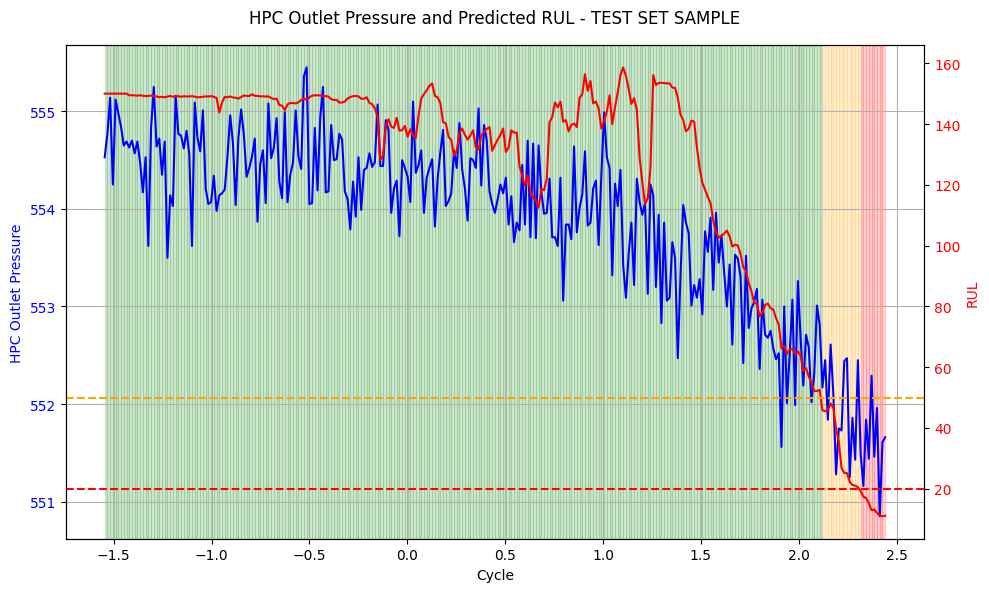

In [145]:
# plot the HPC pressure and the ESTIMATED RUL in the same plot with two y-axes (TEST SAMPLE)

engine_id = df_TEST['engine_id'].unique()[0] # take the first engine in the test set

X_test_sample, y_test_sample = create_windows(df_TEST[df_TEST['engine_id'] == engine_id], window_size=WINDOWS_SIZE)

engine_data = df_TEST[df_TEST['engine_id'] == engine_id]

y_test_sample_pred = model.predict(X_test_sample)
y_test_sample_pred_last = (y_test_sample_pred * train_std['RUL'] ) + train_mean['RUL']
y_test_sample_true_last = (y_test_sample * train_std['RUL'] ) + train_mean['RUL']

cycles = engine_data['cycle'].values
RUL_pred = y_test_sample_pred_last.flatten()  # in case it's shape (n,1)

RUL_pred = [150 for _ in range(0, len(cycles) - len(RUL_pred))] + list(RUL_pred)

print(len(cycles))
print(len(RUL_pred))

def color_from_RUL_pred(lr):
    if lr < 20:
        return 'red'
    elif lr < 50:
        return 'orange'
    else:
        return 'green'

fig, ax1 = plt.subplots(figsize=(10, 6))

# background shading
for i in range(len(cycles) - 1):
    ax1.axvspan(
        cycles[i],
        cycles[i + 1],
        color=color_from_RUL_pred(RUL_pred[i]),
        alpha=0.15
    )

# main signal
ax1.plot(
    cycles,
    (engine_data['HPC_outlet_press'] * train_std['HPC_outlet_press']) + train_mean['HPC_outlet_press'],
    color='b',
    label='HPC Outlet Pressure'
)

ax1.set_xlabel('Cycle')
ax1.set_ylabel('HPC Outlet Pressure', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid()

# second axis
ax2 = ax1.twinx()
ax2.plot(cycles, RUL_pred, color='r', label='Predicted RUL')
ax2.set_ylabel('RUL', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# add an horizontal line at RUL=20 and RUL=50 to visualize the thresholds
ax2.axhline(y=20, color='red', linestyle='--', label='RUL=20 Threshold')
ax2.axhline(y=50, color='orange', linestyle='--', label='RUL=50 Threshold')

fig.suptitle(
    f'HPC Outlet Pressure and Predicted RUL - TEST SET SAMPLE'
)

fig.tight_layout()
plt.show()

In [146]:
engine_data

,engine_id,cycle,altitude,mach_number,LPC_outlet_temp,HPC_outlet_temp,LPT_outlet_temp,bypass_press,HPC_outlet_press,fan_speed,core_speed,HPC_static_outlet_press,fuel_flow_ratio,corrected_fan_speed,corrected_core_speed,bypass_ratio,bleed_enthalpy,HPT_coolant_bleed,LPT_coolant_bleed,RUL
0,2_FD001,-1.546572,-0.814482,2.031468,-1.578300,-1.080204,-1.966423,-7.156614,1.321892,-1.239764,-0.512461,-2.295430,1.246084,-0.500523,-0.345672,-1.371735,-1.419264,0.676712,1.556196,1.073811
1,2_FD001,-1.532626,1.972064,-1.039745,-1.719335,-0.554007,-1.759129,0.139721,1.597160,-1.676689,-0.677630,-1.122196,1.754633,-1.650196,-0.719809,-0.670391,-0.770893,1.345298,1.091128,1.073811
2,2_FD001,-1.518680,0.830037,1.007730,-2.263325,-0.345823,-1.105871,-7.156614,2.021531,-0.802839,-0.535711,-1.197889,1.589698,-1.506487,-0.184280,-1.647454,-1.419264,1.623876,1.244600,1.073811
3,2_FD001,-1.504734,1.606616,-1.380991,-2.001404,-1.029387,-1.428578,0.139721,1.000747,-1.676689,-0.353105,-1.652044,1.465997,-2.368741,-0.192181,-1.069247,-1.419264,1.735307,1.967316,1.073811
4,2_FD001,-1.490788,0.236183,1.348976,-1.900665,-1.868679,-0.706969,-7.156614,1.998592,-0.948481,-0.346324,-1.084350,1.163616,-2.225032,-0.404925,-1.473456,-2.067634,2.013884,1.229718,1.073811
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,2_FD001,2.386196,2.109108,0.666484,2.229631,1.901578,2.335218,0.139721,-2.199240,0.944860,0.912058,2.548891,-1.860190,1.511404,1.749604,2.092155,3.119329,-2.220494,-2.375489,-1.842213
283,2_FD001,2.400142,-0.266309,0.325239,2.491553,1.790109,2.376677,0.139721,-1.625766,1.818709,1.190084,2.435352,-2.025124,1.655113,1.297029,2.338428,1.174218,-3.279089,-1.596035,-1.862186
284,2_FD001,2.414088,-0.311990,1.348976,2.008006,1.050811,2.503294,0.139721,-2.898879,1.527426,1.616326,2.775968,-2.080103,1.798822,1.184167,2.207261,1.822588,-2.387641,-1.634171,-1.882159
285,2_FD001,2.428034,-0.449033,-1.039745,1.544607,2.163856,2.324013,0.139721,-2.027198,1.236143,1.778104,2.283967,-2.629886,1.798822,1.474221,1.377426,1.174218,-2.721934,-2.551285,-1.902132
